In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter

# Gerekli NLTK paketlerini indiriyoruz
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
#Kaynak: Yelp Dataset Challenge (Kaggle/Yelp Official)
#Boyut: Yelp Business veri seti yaklaşık 150.000+ işletme kaydı içerir. Orijinal format JSON'dır.
#Sütun Yapısı: business_id, name, address, city, stars, review_count, categories. Biz analizimizde işletme kategorilerini (categories) metin verisi olarak kullanacağız.

In [21]:
# Veri setini yüklüyoruz (Dosya yolunu kendi bilgisayarına göre güncelle)
file_path = 'yelp_academic_dataset_business.json'

data = []
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5000: break # Örnek olması için ilk 5000 satırı alıyoruz
        data.append(json.loads(line))

df = pd.DataFrame(data)

# Analiz için kategoriler sütununu seçiyoruz ve boş verileri temizliyoruz
df = df[['name', 'categories']].dropna()
df.columns = ['Isletme_Adi', 'Kategoriler']
print("Veri Seti İlk 5 Satır:")
display(df.head())


Veri Seti İlk 5 Satır:


,Isletme_Adi,Kategoriler
0,"Abby Rappoport, LAC, CMQ","Doctors, Traditional Chinese Medicine, Naturop..."
1,The UPS Store,"Shipping Centers, Local Services, Notaries, Ma..."
2,Target,"Department Stores, Shopping, Fashion, Home & G..."
3,St Honore Pastries,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,Perkiomen Valley Brewery,"Brewpubs, Breweries, Food"


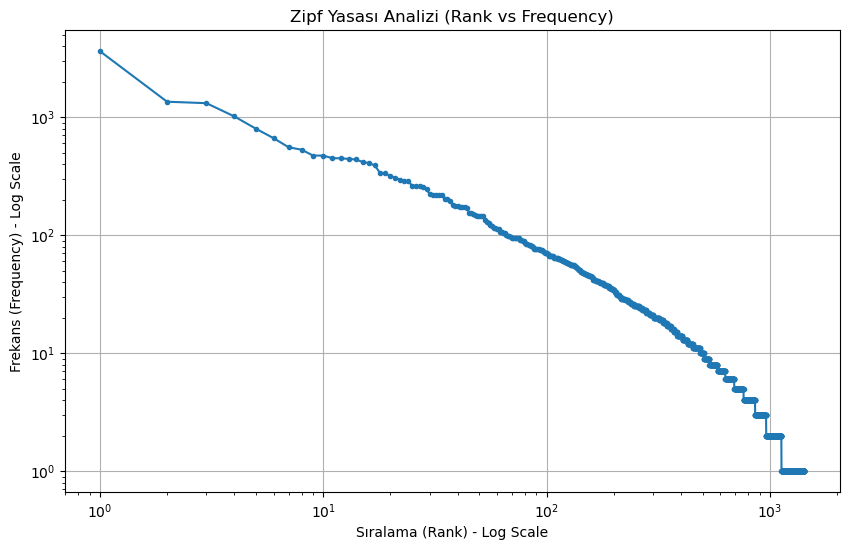

In [22]:
# Tüm kategorileri tek bir devasa metin haline getiriyoruz
ham_metin = " ".join(df['Kategoriler'].astype(str))
kelimeler = ham_metin.split()

# Frekansları hesapla
counts = Counter(kelimeler)
frekanslar = sorted(counts.values(), reverse=True)
siralamalar = range(1, len(frekanslar) + 1)

# Grafik çizimi
plt.figure(figsize=(10, 6))
plt.loglog(siralamalar, frekanslar, marker=".")
plt.title('Zipf Yasası Analizi (Rank vs Frequency)')
plt.xlabel('Sıralama (Rank) - Log Scale')
plt.ylabel('Frekans (Frequency) - Log Scale')
plt.grid(True)
plt.show()

In [23]:
# Kütüphane: re (Regular Expressions)
def temizle_ve_kucult(metin):
    # Sayıları ve özel karakterleri kaldır
    metin = re.sub(r'\d+', '', metin)
    metin = re.sub(r'[^\w\s]', '', metin)
    return metin.lower()

df['Temiz_Kategori'] = df['Kategoriler'].apply(temizle_ve_kucult)

print("--- Önce / Sonra (Lowercasing & Temizlik) ---")
display(df[['Kategoriler', 'Temiz_Kategori']].head())

--- Önce / Sonra (Lowercasing & Temizlik) ---


,Kategoriler,Temiz_Kategori
0,"Doctors, Traditional Chinese Medicine, Naturop...",doctors traditional chinese medicine naturopat...
1,"Shipping Centers, Local Services, Notaries, Ma...",shipping centers local services notaries mailb...
2,"Department Stores, Shopping, Fashion, Home & G...",department stores shopping fashion home garde...
3,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",restaurants food bubble tea coffee tea bakeries
4,"Brewpubs, Breweries, Food",brewpubs breweries food


In [24]:
# Kütüphane: nltk
stop_words = set(stopwords.words('english'))

def tokenize_ve_stopword(metin):
    tokens = nltk.word_tokenize(metin)
    temiz_tokens = [w for w in tokens if w not in stop_words]
    return temiz_tokens

df['Token_Kategori'] = df['Temiz_Kategori'].apply(tokenize_ve_stopword)

print("--- Önce / Sonra (Tokenization & Stop Words) ---")
display(df[['Temiz_Kategori', 'Token_Kategori']].head())

--- Önce / Sonra (Tokenization & Stop Words) ---


,Temiz_Kategori,Token_Kategori
0,doctors traditional chinese medicine naturopat...,"[doctors, traditional, chinese, medicine, natu..."
1,shipping centers local services notaries mailb...,"[shipping, centers, local, services, notaries,..."
2,department stores shopping fashion home garde...,"[department, stores, shopping, fashion, home, ..."
3,restaurants food bubble tea coffee tea bakeries,"[restaurants, food, bubble, tea, coffee, tea, ..."
4,brewpubs breweries food,"[brewpubs, breweries, food]"


In [25]:
# Kütüphaneler: PorterStemmer, WordNetLemmatizer
ps = PorterStemmer()
wnl = WordNetLemmatizer()

# Stemming işlemi
df['Stemmed'] = df['Token_Kategori'].apply(lambda x: [ps.stem(word) for word in x])

# Lemmatization işlemi
df['Lemmatized'] = df['Token_Kategori'].apply(lambda x: [wnl.lemmatize(word) for word in x])

print("--- Final Karşılaştırma (Stemming vs Lemmatization) ---")
display(df[['Token_Kategori', 'Stemmed', 'Lemmatized']].head())

# İstenen CSV dosyalarını kaydetme
df[['Isletme_Adi', 'Stemmed']].to_csv('Stemmed_Veri_Seti.csv', index=False)
df[['Isletme_Adi', 'Lemmatized']].to_csv('Lemmatized_Veri_Seti.csv', index=False)
df.to_csv('Ham_Veri_Seti.csv', index=False)
print("\nDosyalar başarıyla kaydedildi!")

--- Final Karşılaştırma (Stemming vs Lemmatization) ---


,Token_Kategori,Stemmed,Lemmatized
0,"[doctors, traditional, chinese, medicine, natu...","[doctor, tradit, chines, medicin, naturopathic...","[doctor, traditional, chinese, medicine, natur..."
1,"[shipping, centers, local, services, notaries,...","[ship, center, local, servic, notari, mailbox,...","[shipping, center, local, service, notary, mai..."
2,"[department, stores, shopping, fashion, home, ...","[depart, store, shop, fashion, home, garden, e...","[department, store, shopping, fashion, home, g..."
3,"[restaurants, food, bubble, tea, coffee, tea, ...","[restaur, food, bubbl, tea, coffe, tea, bakeri]","[restaurant, food, bubble, tea, coffee, tea, b..."
4,"[brewpubs, breweries, food]","[brewpub, breweri, food]","[brewpub, brewery, food]"



Dosyalar başarıyla kaydedildi!


In [26]:
# Kütüphane: re (Regular Expressions)
import re

def temizle_ve_kucult(metin):
    # 1. Metni stringe çevir (Hata almamak için önemli)
    metin = str(metin)
    # 2. Lowercasing: Tüm metni küçük harfe dönüştür
    metin = metin.lower()
    # 3. HTML etiketlerini, sayıları ve özel karakterleri temizle
    metin = re.sub(r'<.*?>', '', metin) # HTML temizliği
    metin = re.sub(r'\d+', '', metin)    # Sayı temizliği
    metin = re.sub(r'[^\w\s]', '', metin) # Özel karakter temizliği
    return metin

# 'Temiz_Kategori' sütununu burada oluşturuyoruz
df['Temiz_Kategori'] = df['Kategoriler'].apply(temizle_ve_kucult)

print("Temizlik ve Lowercasing tamamlandı. 'Temiz_Kategori' sütunu oluşturuldu.")
# Ödevde istenen Önce/Sonra çıktısı
display(df[['Kategoriler', 'Temiz_Kategori']].head())

Temizlik ve Lowercasing tamamlandı. 'Temiz_Kategori' sütunu oluşturuldu.


,Kategoriler,Temiz_Kategori
0,"Doctors, Traditional Chinese Medicine, Naturop...",doctors traditional chinese medicine naturopat...
1,"Shipping Centers, Local Services, Notaries, Ma...",shipping centers local services notaries mailb...
2,"Department Stores, Shopping, Fashion, Home & G...",department stores shopping fashion home garde...
3,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",restaurants food bubble tea coffee tea bakeries
4,"Brewpubs, Breweries, Food",brewpubs breweries food
